# 0. Install and Import Dependencies

In [1]:
!pip install mediapipe opencv-python pandas scikit-learn pyttsx3 matplotlib

In [2]:
import mediapipe as mp # Import mediapipe
import cv2 # Import opencv
import pyttsx3
import sys
sys.path.insert(0, 'C:\\Users\\harsh\\Downloads\\Body-Language-Decoder-main\\Body-Language-Decoder-main\\Silent-Face-Anti-Spoofing-master')
from mytest import test
engine = pyttsx3.init()

In [3]:
mp_drawing = mp.solutions.drawing_utils # Drawing helpers
mp_holistic = mp.solutions.holistic # Mediapipe Solutions

# 1. Make Some Detections

In [4]:
cap = cv2.VideoCapture(0)
# Initiate holistic model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    while cap.isOpened():
        ret, frame = cap.read()
        
        # Recolor Feed
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False        
        
        # Make Detections
        results = holistic.process(image)
        # print(results.face_landmarks)
        
        # face_landmarks, pose_landmarks, left_hand_landmarks, right_hand_landmarks
        
        # Recolor image back to BGR for rendering
        image.flags.writeable = True   
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        # 1. Draw face landmarks
        mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                                 mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
                                 mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                                 )
        
        # 2. Right hand
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                 mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
                                 mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                                 )

        # 3. Left Hand
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                 mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
                                 mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                                 )

        # 4. Pose Detections
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
                                 mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
                                 mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                                 )
                        
        cv2.imshow('Raw Webcam Feed', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

In [5]:
results.face_landmarks.landmark[0].visibility

0.0

# 2. Capture Landmarks & Export to CSV
<!--<img src="https://i.imgur.com/8bForKY.png">-->
<!--<img src="https://i.imgur.com/AzKNp7A.png">-->

In [6]:
import csv
import os
import numpy as np

In [7]:
num_coords = len(results.pose_landmarks.landmark)+len(results.face_landmarks.landmark)
num_coords

501

In [8]:
landmarks = ['class']
for val in range(1, num_coords+1):
    landmarks += ['x{}'.format(val), 'y{}'.format(val), 'z{}'.format(val), 'v{}'.format(val)]

In [9]:
landmarks

['class',
 'x1',
 'y1',
 'z1',
 'v1',
 'x2',
 'y2',
 'z2',
 'v2',
 'x3',
 'y3',
 'z3',
 'v3',
 'x4',
 'y4',
 'z4',
 'v4',
 'x5',
 'y5',
 'z5',
 'v5',
 'x6',
 'y6',
 'z6',
 'v6',
 'x7',
 'y7',
 'z7',
 'v7',
 'x8',
 'y8',
 'z8',
 'v8',
 'x9',
 'y9',
 'z9',
 'v9',
 'x10',
 'y10',
 'z10',
 'v10',
 'x11',
 'y11',
 'z11',
 'v11',
 'x12',
 'y12',
 'z12',
 'v12',
 'x13',
 'y13',
 'z13',
 'v13',
 'x14',
 'y14',
 'z14',
 'v14',
 'x15',
 'y15',
 'z15',
 'v15',
 'x16',
 'y16',
 'z16',
 'v16',
 'x17',
 'y17',
 'z17',
 'v17',
 'x18',
 'y18',
 'z18',
 'v18',
 'x19',
 'y19',
 'z19',
 'v19',
 'x20',
 'y20',
 'z20',
 'v20',
 'x21',
 'y21',
 'z21',
 'v21',
 'x22',
 'y22',
 'z22',
 'v22',
 'x23',
 'y23',
 'z23',
 'v23',
 'x24',
 'y24',
 'z24',
 'v24',
 'x25',
 'y25',
 'z25',
 'v25',
 'x26',
 'y26',
 'z26',
 'v26',
 'x27',
 'y27',
 'z27',
 'v27',
 'x28',
 'y28',
 'z28',
 'v28',
 'x29',
 'y29',
 'z29',
 'v29',
 'x30',
 'y30',
 'z30',
 'v30',
 'x31',
 'y31',
 'z31',
 'v31',
 'x32',
 'y32',
 'z32',
 'v32',
 '

In [10]:
with open('coords.csv', mode='w', newline='') as f:
    csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
    csv_writer.writerow(landmarks)

In [17]:
class_name = "victory"

In [18]:
# Path to the folder containing images
folder_path = r'C:\\Users\\harsh\Downloads\Body-Language-Decoder-main\Body-Language-Decoder-main\\victory'

# Iterate over images in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.jpeg'):
        # Read image
        image_path = os.path.join(folder_path, filename)
        frame = cv2.imread(image_path)
        #resized_frame = cv2.resize(frame, (640, 480))
        # Recolor Feed
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False

        # Make Detections
        with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
            results = holistic.process(image)

        # Recolor image back to BGR for rendering
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        try:
            # Extract Pose landmarks
            pose = results.pose_landmarks.landmark
            pose_row = list(np.array([[landmark.x, landmark.y, landmark.z, landmark.visibility] for landmark in pose]).flatten())

            # Extract Face landmarks
            face = results.face_landmarks.landmark
            face_row = list(np.array([[landmark.x, landmark.y, landmark.z, landmark.visibility] for landmark in face]).flatten())

            # Concatenate rows
            row = pose_row + face_row

            # Append class name
            row.insert(0, class_name)

            # Export to CSV
            with open('coords.csv', mode='a', newline='') as f:
                csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
                csv_writer.writerow(row)

        except:
            pass
cv2.destroyAllWindows()

# 3. Train Custom Model Using Scikit Learn

## 3.1 Read in Collected Data and Process

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [21]:
df = pd.read_csv('coords.csv')

In [22]:
df.head()

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,z499,v499,x500,y500,z500,v500,x501,y501,z501,v501
0,hii,0.347163,0.625783,-0.386748,0.999999,0.361022,0.593417,-0.359817,0.999997,0.368106,...,-0.004554,0.0,0.371599,0.591636,0.000286,0.0,0.373726,0.588827,0.000214,0.0
1,hii,0.529458,0.610774,-0.320882,1.000000,0.541231,0.574294,-0.290267,0.999999,0.548098,...,-0.003452,0.0,0.555182,0.586460,0.003910,0.0,0.557148,0.583104,0.004084,0.0
2,hii,0.347163,0.625783,-0.386748,0.999999,0.361022,0.593417,-0.359817,0.999997,0.368106,...,-0.004554,0.0,0.371599,0.591636,0.000286,0.0,0.373726,0.588827,0.000214,0.0
3,hii,0.480496,0.618160,-0.572226,0.999986,0.492129,0.582916,-0.544087,0.999962,0.498652,...,-0.002949,0.0,0.506929,0.582978,0.003136,0.0,0.508989,0.580257,0.003241,0.0
4,hii,0.580860,0.616458,-0.300986,0.999998,0.592217,0.580253,-0.271122,0.999996,0.598849,...,-0.005683,0.0,0.599661,0.582831,-0.001695,0.0,0.601681,0.579211,-0.001787,0.0


In [23]:
df.tail()

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,z499,v499,x500,y500,z500,v500,x501,y501,z501,v501
62,victory,0.480432,0.621460,-0.362316,0.999984,0.492763,0.587524,-0.344603,0.999974,0.498815,...,-0.003469,0.0,0.507446,0.590134,0.003759,0.0,0.509225,0.587967,0.003909,0.0
63,victory,0.375246,0.606404,-0.410906,0.999912,0.388072,0.575172,-0.381361,0.999804,0.395439,...,-0.001135,0.0,0.399965,0.583276,0.007492,0.0,0.402145,0.581031,0.007805,0.0
64,victory,0.378677,0.603957,-0.378165,0.999968,0.392518,0.576762,-0.351388,0.999918,0.399698,...,-0.001563,0.0,0.405337,0.581483,0.007426,0.0,0.407468,0.579336,0.007789,0.0
65,victory,0.480371,0.628546,-0.385361,0.999972,0.493872,0.595072,-0.363206,0.999948,0.500378,...,-0.003731,0.0,0.511992,0.592849,0.003582,0.0,0.513787,0.590634,0.003703,0.0
66,victory,0.380249,0.608484,-0.473878,0.999821,0.393142,0.578473,-0.439442,0.999648,0.400655,...,-0.002062,0.0,0.403420,0.582224,0.006951,0.0,0.405489,0.580316,0.007263,0.0


In [24]:
df[df['class']=='Sad']

,class,x1,y1,z1,v1,x2,y2,z2,v2,x3,...,z499,v499,x500,y500,z500,v500,x501,y501,z501,v501


In [25]:
X = df.drop('class', axis=1) # features
y = df['class'] # target value

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

In [27]:
y_test

22    standing
33     sitting
42     sitting
8          hii
6          hii
59     victory
35     sitting
20    standing
4          hii
21    standing
45     sitting
60     victory
62     victory
18    standing
66     victory
31    standing
64     victory
13         hii
25    standing
61     victory
27    standing
Name: class, dtype: object

## 3.2 Train Machine Learning Classification Model

In [28]:
from sklearn.pipeline import make_pipeline 
from sklearn.preprocessing import StandardScaler 

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [29]:
pipelines = {
    'lr':make_pipeline(StandardScaler(), LogisticRegression()),
    'rc':make_pipeline(StandardScaler(), RidgeClassifier()),
    'rf':make_pipeline(StandardScaler(), RandomForestClassifier()),
    'gb':make_pipeline(StandardScaler(), GradientBoostingClassifier()),
}

In [30]:
fit_models = {}
for algo, pipeline in pipelines.items():
    model = pipeline.fit(X_train, y_train)
    fit_models[algo] = model

In [31]:
fit_models

{'lr': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression', LogisticRegression())]),
 'rc': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('ridgeclassifier', RidgeClassifier())]),
 'rf': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier', RandomForestClassifier())]),
 'gb': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('gradientboostingclassifier', GradientBoostingClassifier())])}

In [32]:
fit_models['rc'].predict(X_test)

array(['standing', 'sitting', 'sitting', 'hii', 'hii', 'victory',
       'sitting', 'standing', 'hii', 'standing', 'sitting', 'victory',
       'victory', 'standing', 'victory', 'standing', 'victory',
       'standing', 'standing', 'victory', 'standing'], dtype='<U8')

## 3.3 Evaluate and Serialize Model 

In [33]:
from sklearn.metrics import accuracy_score # Accuracy metrics 
import pickle 

In [34]:
for algo, model in fit_models.items():
    yhat = model.predict(X_test)
    print(algo, accuracy_score(y_test, yhat))

lr 0.9047619047619048
rc 0.9523809523809523
rf 1.0
gb 1.0


In [35]:
fit_models['rf'].predict(X_test)

array(['standing', 'sitting', 'sitting', 'hii', 'hii', 'victory',
       'sitting', 'standing', 'hii', 'standing', 'sitting', 'victory',
       'victory', 'standing', 'victory', 'standing', 'victory', 'hii',
       'standing', 'victory', 'standing'], dtype=object)

In [36]:
y_test

22    standing
33     sitting
42     sitting
8          hii
6          hii
59     victory
35     sitting
20    standing
4          hii
21    standing
45     sitting
60     victory
62     victory
18    standing
66     victory
31    standing
64     victory
13         hii
25    standing
61     victory
27    standing
Name: class, dtype: object

In [37]:
with open('body_language.pkl', 'wb') as f:
    pickle.dump(fit_models['rf'], f)

# 4. Make Detections with Model

In [38]:
with open('body_language.pkl', 'rb') as f:
    model = pickle.load(f)

In [39]:
model

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier', RandomForestClassifier())])

In [40]:
cap = cv2.VideoCapture(0)
##cap.set(cv2.CAP_PROP_FRAME_WIDTH, 680)
##cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
prev_body_language_class=""
# Initiate holistic model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    process_every_n_frames = 5
    frame_counter = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_counter += 1
        if frame_counter % process_every_n_frames != 0:
            continue
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False  
        tup = test(image=image,model_dir="Silent-Face-Anti-Spoofing-master\\resources\\anti_spoof_models", device_id=0)
        results = holistic.process(image)
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        image.flags.writeable = True   
        if(tup[0]==1 and tup[1]>0.05):    
            
            # 1. Draw face landmarks
            mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                                    mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
                                    mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                                    )
            
            # 2. Right hand
            mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                    mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
                                    mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                                    )

            # 3. Left Hand
            mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                    mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
                                    mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                                    )

            # 4. Pose Detections
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
                                    mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
                                    mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                                    )
            
            try:
                # Extract Pose landmarks
                pose = results.pose_landmarks.landmark
                pose_row = list(np.array([[landmark.x, landmark.y, landmark.z, landmark.visibility] for landmark in pose]).flatten())
                
                # Extract Face landmarks
                face = results.face_landmarks.landmark
                face_row = list(np.array([[landmark.x, landmark.y, landmark.z, landmark.visibility] for landmark in face]).flatten())
                
                # Concate rows
                row = pose_row+face_row
                
                X = pd.DataFrame([row])
                body_language_class = model.predict(X)[0]
                body_language_prob = model.predict_proba(X)[0]
                print(body_language_class, body_language_prob)
                
                # Get status box
                cv2.rectangle(image, (0,0), (250, 60), (245, 117, 16), -1)
                
                # Display Class
                cv2.putText(image, 'CLASS'
                            , (95,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                cv2.putText(image, body_language_class.split(' ')[0]
                            , (90,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
                
                if prev_body_language_class!=body_language_class:
                    engine.say(body_language_class)
                    engine.runAndWait()
                    engine.stop()
                    prev_body_language_class=body_language_class
                # Display Probability
                
                cv2.putText(image, 'PROB'
                            , (15,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                cv2.putText(image, str(round(body_language_prob[np.argmax(body_language_prob)],2))
                            , (10,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
                
            except:
                pass
        else:
            cv2.rectangle(image, (0,0), (250, 60), (245, 117, 16), -1)
                
                # Display Class
            cv2.putText(image, "spoof"
                            , (90,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
            cv2.putText(image, 'PROB'
                            , (15,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
            cv2.putText(image, str(round(tup[1],2)), (10,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
                        
        cv2.imshow('Raw Webcam Feed', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

standing [0.04 0.04 0.89 0.03]
standing [0.   0.19 0.77 0.04]
standing [0.   0.14 0.82 0.04]
standing [0.   0.21 0.75 0.04]
standing [0.   0.06 0.92 0.02]
standing [0.02 0.06 0.9  0.02]
standing [0.03 0.04 0.9  0.03]
standing [0.   0.04 0.94 0.02]
standing [0.   0.03 0.92 0.05]
standing [0.   0.04 0.94 0.02]
standing [0.   0.04 0.94 0.02]
standing [0.   0.04 0.93 0.03]
standing [0.   0.04 0.93 0.03]
standing [0.   0.03 0.95 0.02]
standing [0.   0.03 0.95 0.02]
standing [0.04 0.03 0.91 0.02]
standing [0.04 0.03 0.89 0.04]
standing [0.04 0.03 0.89 0.04]
standing [0.04 0.03 0.91 0.02]
standing [0.04 0.02 0.9  0.04]
standing [0.04 0.02 0.9  0.04]
standing [0.04 0.02 0.92 0.02]
standing [0.04 0.02 0.9  0.04]
standing [0.04 0.02 0.92 0.02]
standing [0.04 0.02 0.92 0.02]
standing [0.04 0.02 0.9  0.04]
standing [0.03 0.03 0.92 0.02]
standing [0.04 0.02 0.94 0.  ]
standing [0.04 0.02 0.94 0.  ]
standing [0.04 0.02 0.93 0.01]
standing [0.03 0.03 0.93 0.01]
standing [0.03 0.03 0.94 0.  ]
standing

In [41]:
tuple(np.multiply(np.array((results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_EAR].x, 
results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_EAR].y)), [640,480]).astype(int))

(541, 330)

In [42]:
_true=[]
pred=[]


In [43]:
# Path to the folder containing images
mylist=["sitting","standing","victory","hii"]
for item in mylist:
    actual= item
    folder_path = r'C:\\Users\\harsh\Downloads\Body-Language-Decoder-main\Body-Language-Decoder-main\\test\\'+actual

    # Iterate over images in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('.jpeg'):
            # Read image
            image_path = os.path.join(folder_path, filename)

            prev_body_language_class=""
    # Initiate holistic model       

            with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
                process_every_n_frames = 10
                frame_counter = 0
                
                frame = cv2.imread(image_path)
                image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                image.flags.writeable = False  
               
                results = holistic.process(image)
                image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
                image.flags.writeable = True   
                 
                        
                    # 1. Draw face landmarks
                mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                                                mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
                                                mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                                                )
                        
                    # 2. Right hand
                mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                                mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
                                                mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                                                )

                    # 3. Left Hand
                mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                                mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
                                                mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                                                )

                    # 4. Pose Detections
                mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
                                                mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
                                                mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                                                )
                        
                try:
                    # Extract Pose landmarks
                    pose = results.pose_landmarks.landmark
                    pose_row = list(np.array([[landmark.x, landmark.y, landmark.z, landmark.visibility] for landmark in pose]).flatten())
                            
                            # Extract Face landmarks
                    face = results.face_landmarks.landmark
                    face_row = list(np.array([[landmark.x, landmark.y, landmark.z, landmark.visibility] for landmark in face]).flatten())
                            
                            # Concate rows
                    row = pose_row+face_row
                            
                    X = pd.DataFrame([row])
                    body_language_class = model.predict(X)[0]
                    body_language_prob = model.predict_proba(X)[0]
                    print(body_language_class, body_language_prob)
                    _true.append(item)
                    pred.append(body_language_class)
                            
                            # Get status box
                    cv2.rectangle(image, (0,0), (250, 60), (245, 117, 16), -1)
                            
                            # Display Class
                    cv2.putText(image, 'CLASS'
                                        , (95,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                    cv2.putText(image, body_language_class.split(' ')[0]
                                        , (90,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
                            
                    if prev_body_language_class!=body_language_class:
                        engine.say(body_language_class)
                        engine.runAndWait()
                        engine.stop()
                        prev_body_language_class=body_language_class
                            # Display Probability
                            
                    cv2.putText(image, 'PROB'
                                        , (15,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                    cv2.putText(image, str(round(body_language_prob[np.argmax(body_language_prob)],2))
                                        , (10,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
                            
                except:
                    pass
            
            cv2.imshow('Raw Webcam Feed', image)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                 break

cv2.destroyAllWindows()

victory [0.28 0.34 0.01 0.37]
hii [0.42 0.3  0.01 0.27]
sitting [0.37 0.42 0.01 0.2 ]
hii [0.43 0.38 0.   0.19]
hii [0.81 0.07 0.   0.12]
hii [0.58 0.15 0.02 0.25]
hii [0.47 0.19 0.01 0.33]
hii [0.56 0.23 0.   0.21]
standing [0.01 0.   0.96 0.03]
standing [0.02 0.02 0.96 0.  ]
standing [0.   0.02 0.97 0.01]
standing [0.   0.01 0.99 0.  ]
standing [0.   0.05 0.93 0.02]
standing [0.04 0.02 0.92 0.02]
standing [0.04 0.01 0.94 0.01]
standing [0.   0.   0.99 0.01]
standing [0.   0.01 0.99 0.  ]
standing [0.04 0.   0.94 0.02]
standing [0.   0.01 0.98 0.01]
standing [0.   0.04 0.94 0.02]
hii [0.48 0.09 0.01 0.42]
hii [0.45 0.1  0.02 0.43]
hii [0.5  0.08 0.01 0.41]
hii [0.45 0.08 0.02 0.45]
hii [0.46 0.11 0.01 0.42]
hii [0.56 0.07 0.01 0.36]
hii [0.51 0.08 0.   0.41]
victory [0.25 0.1  0.01 0.64]
victory [0.44 0.06 0.   0.5 ]
victory [0.32 0.1  0.01 0.57]
hii [0.72 0.05 0.   0.23]
hii [0.89 0.02 0.   0.09]
hii [0.7  0.06 0.01 0.23]
hii [0.73 0.07 0.   0.2 ]
hii [0.74 0.08 0.   0.18]
hii [0.78 

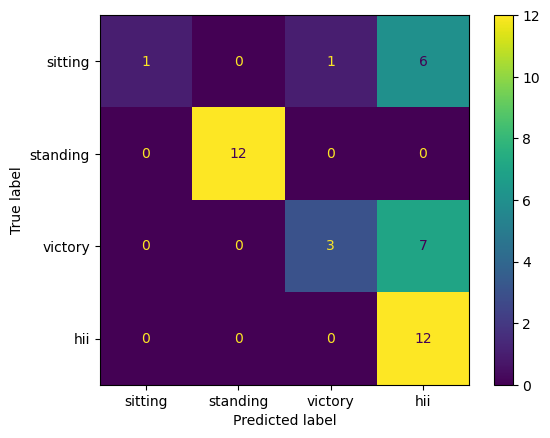

In [44]:
from sklearn import metrics
import matplotlib.pyplot as plt

result=metrics.confusion_matrix(_true,pred,labels=mylist)
_display=metrics.ConfusionMatrixDisplay(confusion_matrix=result,display_labels=mylist)
_display.plot()
plt.show()